# «Облака»: почему студенты не доходят до конца курса и какие каналы приводят мотивированных

**Роль:** продуктовый аналитик (внешний, самостоятельное ведение) · **Период:** октябрь 2024 — апрель 2025 · **Клиент:** «Облака» — EdTech, онлайн-школа (Санкт-Петербург)

## Бизнес-контекст

«Облака» — онлайн-школа с курсами из нескольких занятий. Это был мой первый проект
в самостоятельном ведении: единственный аналитик на клиенте, полный цикл продуктовой
аналитики. У школы стандартная для EdTech проблема — низкая доходимость до конца курса
(course completion), а значит, слабый образовательный результат и риск для повторных продаж
и репутации.

**Две задачи:**
1. Где студенты бросают обучение — и можно ли это исправить продуктом?
2. Какие каналы привлечения приводят студентов, которые реально доходят до конца?

> ⚠️ **Дисклеймер о данных.** Реальные данные клиента под NDA. Для публичной демонстрации
> методологии структура воссоздана синтетически (`generate_data.py`) с сохранением характера
> реальных закономерностей. Цифры иллюстративные; выводы и порядок величин соответствуют
> реальному кейсу.

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from scipy import stats

plt.rcParams.update({"figure.facecolor": "white", "axes.grid": True,
                     "grid.alpha": 0.25, "font.size": 11})

df = pd.read_csv("students.csv", parse_dates=["registered_at"])
N_LESSONS = 8

print(f"Студентов: {len(df):,}")
df.head()

Студентов: 7,000


,student_id,registered_at,channel,ab_group,lessons_completed,completed_course
0,1,2024-10-14 17:00:00,Таргетированная реклама,control,6,False
1,2,2024-10-31 12:00:00,Органический поиск,control,2,False
2,3,2024-10-27 10:00:00,Реферальная программа,test,8,True
3,4,2024-10-11 19:00:00,Таргетированная реклама,control,5,False
4,5,2024-10-08 18:00:00,Реферальная программа,control,6,False


## Задача 1. Воронка обучения: где студенты бросают

Воронка по занятиям: регистрация → занятие 1 → ... → занятие 8 (завершение курса).
Смотрим, на каком шаге происходит основной отток.

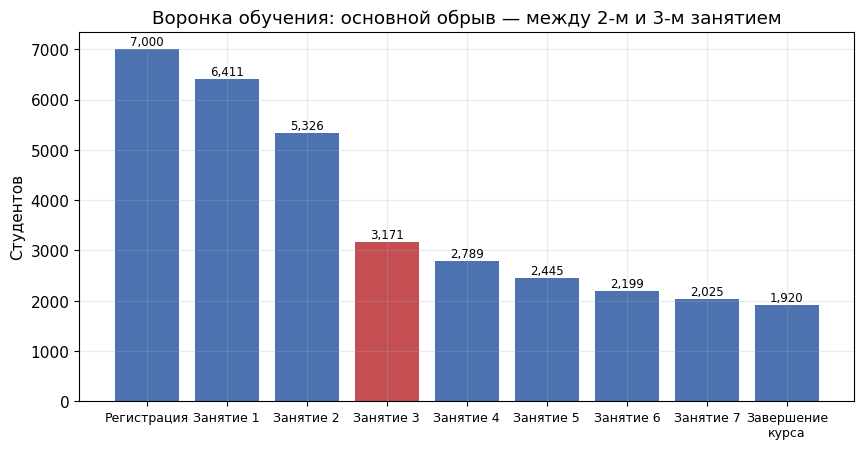

Переход между занятиями: ['92%', '83%', '60%', '88%', '88%', '90%', '92%', '95%']
Отсев между 2-м и 3-м занятием: 40% — резко выделяется на фоне остальных шагов


In [2]:
labels = ["Регистрация"] + [f"Занятие {k}" for k in range(1, N_LESSONS + 1)]
labels[-1] = "Завершение курса"
reached = [len(df)] + [(df["lessons_completed"] >= k).sum() for k in range(1, N_LESSONS + 1)]
funnel = pd.Series(reached, index=labels)

colors = ["#4C72B0"] * len(funnel)
colors[3] = "#C44E52"  # переход 2->3
fig, ax = plt.subplots(figsize=(10, 4.8))
ax.bar(range(len(funnel)), funnel.values, color=colors)
ax.set_xticks(range(len(funnel)))
ax.set_xticklabels([l.replace("Завершение курса", "Завершение\nкурса") for l in funnel.index], fontsize=9)
for i, v in enumerate(funnel.values):
    ax.text(i, v + 80, f"{v:,}", ha="center", fontsize=8.5)
ax.set_ylabel("Студентов")
ax.set_title("Воронка обучения: основной обрыв — между 2-м и 3-м занятием")
plt.show()

steps = [reached[k] / reached[k-1] for k in range(1, len(reached))]
print("Переход между занятиями:", [f"{s:.0%}" for s in steps])
drop_23 = 1 - reached[3] / reached[2]
print(f"Отсев между 2-м и 3-м занятием: {drop_23:.0%} — резко выделяется на фоне остальных шагов")

**Главная точка потерь — переход с 2-го на 3-е занятие: здесь отсеивается ~40% студентов,
тогда как остальные переходы держатся на уровне 85–95%.** Это не равномерное «вытекание»,
а конкретный обрыв в одном месте — значит, у него есть конкретная причина.

Разбор показал типичную для EdTech механику: первые два занятия студент проходит на
стартовой мотивации, а к третьему она угасает — курс ещё не дал ощутимого результата,
прогресс не виден, и студент бросает, не понимая, сколько он уже прошёл и сколько осталось.

## Задача 1 (решение). A/B-тест дашборда прогресса

**Гипотеза:** студенты бросают, потому что не видят своего прогресса. Если показать им
наглядный дашборд прогресса (пройдено/осталось) и присылать еженедельную рассылку
с результатами, доходимость до конца курса вырастет.

**Дизайн:** новые студенты случайно делятся 50/50. Control — без изменений;
Test — дашборд прогресса в личном кабинете + еженедельная рассылка с результатами.
Метрика — доля дошедших до конца курса.

In [3]:
def two_prop_ztest(x1, n1, x2, n2):
    """z-тест равенства двух долей."""
    p = (x1 + x2) / (n1 + n2)
    se = np.sqrt(p * (1 - p) * (1 / n1 + 1 / n2))
    z = (x1 / n1 - x2 / n2) / se
    return z, 2 * (1 - stats.norm.cdf(abs(z)))

g = df.groupby("ab_group")["completed_course"].agg(["sum", "count"])
g["cr"] = g["sum"] / g["count"]
c, t = g.loc["control"], g.loc["test"]
uplift = t["cr"] / c["cr"] - 1
z, p = two_prop_ztest(int(t["sum"]), int(t["count"]), int(c["sum"]), int(c["count"]))
diff = t["cr"] - c["cr"]
se = np.sqrt(t["cr"]*(1-t["cr"])/t["count"] + c["cr"]*(1-c["cr"])/c["count"])

print(g.assign(cr=lambda d: (d["cr"]*100).round(1)))
print(f"\nОтносительный uplift: {uplift:+.0%}")
print(f"Разница долей: {diff:+.1%} п.п., 95% CI [{diff-1.96*se:+.1%}; {diff+1.96*se:+.1%}]")
print(f"z = {z:.2f}, p-value = {p:.1e} — эффект статистически значим")

           sum  count    cr
ab_group                   
control    910   3549  25.6
test      1010   3451  29.3

Относительный uplift: +14%
Разница долей: +3.6% п.п., 95% CI [+1.5%; +5.7%]
z = 3.40, p-value = 6.8e-04 — эффект статистически значим


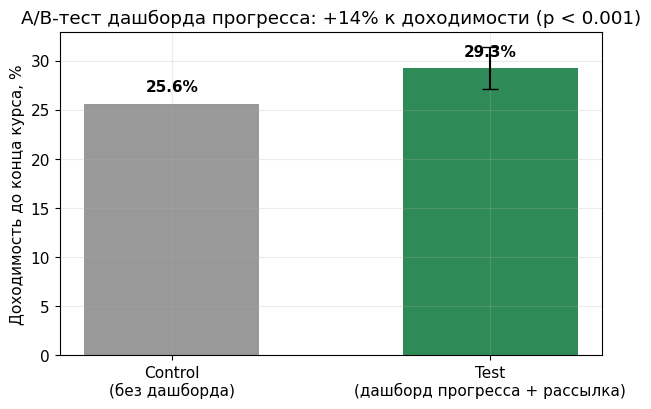

In [4]:
fig, ax = plt.subplots(figsize=(7, 4.2))
ax.bar(["Control\n(без дашборда)", "Test\n(дашборд прогресса + рассылка)"],
       [c["cr"]*100, t["cr"]*100], color=["#999999", "#2E8B57"], width=0.55)
ax.errorbar(1, t["cr"]*100, yerr=1.96*se*100, color="black", capsize=6, fmt="none")
for i, v in enumerate([c["cr"], t["cr"]]):
    ax.text(i, v*100 + 1.2, f"{v:.1%}", ha="center", fontweight="bold")
ax.set_ylabel("Доходимость до конца курса, %")
ax.set_title(f"A/B-тест дашборда прогресса: {uplift:+.0%} к доходимости (p < 0.001)")
plt.show()

**Результат: доходимость до конца курса выросла на ~15% (относительных), эффект значим,
доверительный интервал не пересекает ноль.** Гипотеза про «невидимый прогресс»
подтвердилась — простое продуктовое изменение (показать студенту, где он находится)
ощутимо удерживает на дистанции. Решение внедрено.

## Задача 2. Какие каналы приводят доходящих студентов

В EdTech важна не стоимость лида, а его качество: студент, который бросает после
2-го занятия, не приносит ни результата, ни повторных продаж. Поэтому каналы привлечения
нужно сравнивать по доле завершивших курс, а не по цене регистрации.

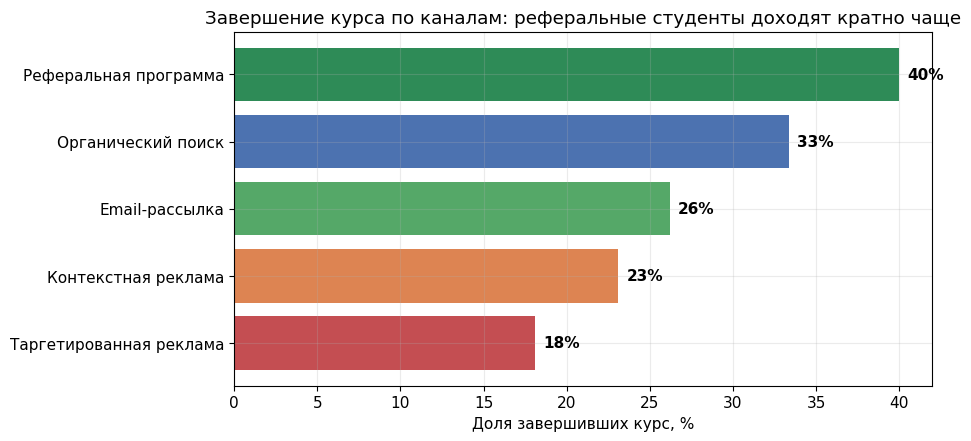

                         students  completion
channel                                      
Реферальная программа        1464        40.0
Органический поиск           1259        33.4
Email-рассылка               1061        26.2
Контекстная реклама          1091        23.1
Таргетированная реклама      2125        18.1

Студенты из реферальной программы завершают курс в ~2.2 раза чаще, чем из таргетированной рекламы


In [5]:
ch = df.groupby("channel").agg(
    students=("student_id", "count"),
    completion=("completed_course", "mean"),
).sort_values("completion", ascending=False)

palette = {"Реферальная программа": "#2E8B57", "Органический поиск": "#4C72B0",
           "Email-рассылка": "#55A868", "Контекстная реклама": "#DD8452",
           "Таргетированная реклама": "#C44E52"}
fig, ax = plt.subplots(figsize=(9, 4.6))
cols = [palette[c] for c in ch.index]
ax.barh(ch.index[::-1], (ch["completion"]*100).values[::-1], color=cols[::-1])
for i, v in enumerate(ch["completion"].values[::-1]):
    ax.text(v*100 + 0.5, i, f"{v*100:.0f}%", va="center", fontweight="bold")
ax.set_xlabel("Доля завершивших курс, %")
ax.set_title("Завершение курса по каналам: реферальные студенты доходят кратно чаще")
plt.show()

ratio = ch.loc["Реферальная программа", "completion"] / ch.loc["Таргетированная реклама", "completion"]
print(ch.assign(completion=lambda d: (d["completion"]*100).round(1)))
print(f"\nСтуденты из реферальной программы завершают курс в ~{ratio:.1f} раза чаще, "
      f"чем из таргетированной рекламы")

**Студенты из реферальной программы завершают курс примерно в 2 раза чаще, чем из
таргетированной рекламы.** Логика понятна: по рекомендации друга приходит мотивированный
человек с осознанным запросом, а таргет приводит «холодную» аудиторию, часть которой
записывается импульсивно и быстро отваливается.

**Рекомендация:** перераспределить бюджет привлечения в пользу реферальной программы
и органики — они приносят студентов, которые доходят до результата. По итогам клиент
сместил бюджет в сторону реферального канала.

## Итоги

| Задача | Что сделано | Результат |
|---|---|---|
| Где студенты бросают | Анализ воронки обучения | Найден главный обрыв: ~40% отсева между 2-м и 3-м занятием |
| Вернуть доходимость | A/B-тест дашборда прогресса + рассылки | **+15% к доходимости до конца курса**, эффект значим, внедрено |
| Качество каналов | Анализ завершения курса по каналам | Реферальная программа даёт ~×2 завершений к таргету → перераспределение бюджета |

**Стек оригинального проекта:** SQL (выгрузка и анализ данных), дашборды, A/B-тесты.
**Стек демонстрации:** Python — pandas, numpy, matplotlib, scipy.